In [ ]:
# Import libraries
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

/Users/prathameshkale/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Load and preprocess MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Use subset for faster training
x_train, y_train = x_train[:5000], y_train[:5000]
x_test, y_test = x_test[:1000], y_test[:1000]

# Convert grayscale to RGB and resize to 224x224
x_train = np.stack([x_train] * 3, axis=-1)
x_test = np.stack([x_test] * 3, axis=-1)
x_train = tf.image.resize(x_train, [224, 224]).numpy() / 255.0
x_test = tf.image.resize(x_test, [224, 224]).numpy() / 255.0

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print(f"Train shape: {x_train.shape}, Test shape: {x_test.shape}")

Train shape: (5000, 224, 224, 3), Test shape: (1000, 224, 224, 3)


## Step 1: Load Pre-trained Model (VGG16)

In [3]:
# Load VGG16 pre-trained on ImageNet, without top layers
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
print("Pre-trained model loaded!")

Pre-trained model loaded!


## Step 2: Freeze Base Model Layers

In [4]:
# Freeze all layers in base model
for layer in base_model.layers:
    layer.trainable = False

print(f"Frozen {len(base_model.layers)} layers")

Frozen 19 layers


## Step 3: Add Custom Classifier

In [5]:
# Build custom classifier on top
x = base_model.output
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(10, activation='softmax')(x)

# Create final model
model = Model(inputs=base_model.input, outputs=output)

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Custom classifier added!")
model.summary()

Custom classifier added!


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,29

 Total params: 21,171,658 (80.76 MB)

 Trainable params: 6,456,970 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Step 4: Train Classifier Layers

In [6]:
# Train only the classifier (base model frozen)
print("Training custom classifier...")
history = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=3,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc:.4f}")

Training custom classifier...
Epoch 1/3
Epoch 1/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 492s 8s/step - accuracy: 0.3372 - loss: 2.1999 - val_accuracy: 0.9530 - val_loss: 0.2848
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 492s 8s/step - accuracy: 0.3372 - loss: 2.1999 - val_accuracy: 0.9530 - val_loss: 0.2848
Epoch 2/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 417s 7s/step - accuracy: 0.7751 - loss: 0.6666 - val_accuracy: 0.9690 - val_loss: 0.1380
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 417s 7s/step - accuracy: 0.7751 - loss: 0.6666 - val_accuracy: 0.9690 - val_loss: 0.1380
Epoch 3/3
63/63 ━━━━━━━━━━━━━━━━━━━━ 449s 7s/step - accuracy: 0.8534 - loss: 0.4348 - val_accuracy: 0.9610 - val_loss: 0.1290
63/63 ━━━━━━━━━━━━━━━━━━━━ 449s 7s/step - accuracy: 0.8534 - loss: 0.4348 - val_accuracy: 0.9610 - val_loss: 0.1290

Test Accuracy: 0.9600

Test Accuracy: 0.9600


## Step 5: Fine-tune Model (Unfreeze Some Layers)

In [8]:
# Unfreeze last 4 layers of base model
for layer in base_model.layers[-4:]:
    layer.trainable = True

print(f"Unfrozen last 4 layers for fine-tuning")

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Fine-tune
print("\nFine-tuning model...")
history_fine = model.fit(
    x_train, y_train,
    batch_size=64,
    epochs=2,
    validation_split=0.2,
    verbose=1
)

# Final evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

Unfrozen last 4 layers for fine-tuning

Fine-tuning model...
Epoch 1/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 575s 9s/step - accuracy: 0.9236 - loss: 0.2342 - val_accuracy: 0.9780 - val_loss: 0.0818
Epoch 2/2
63/63 ━━━━━━━━━━━━━━━━━━━━ 607s 10s/step - accuracy: 0.9306 - loss: 0.1800 - val_accuracy: 0.9800 - val_loss: 0.0806

Final Test Accuracy: 0.9840


## Visualize Results

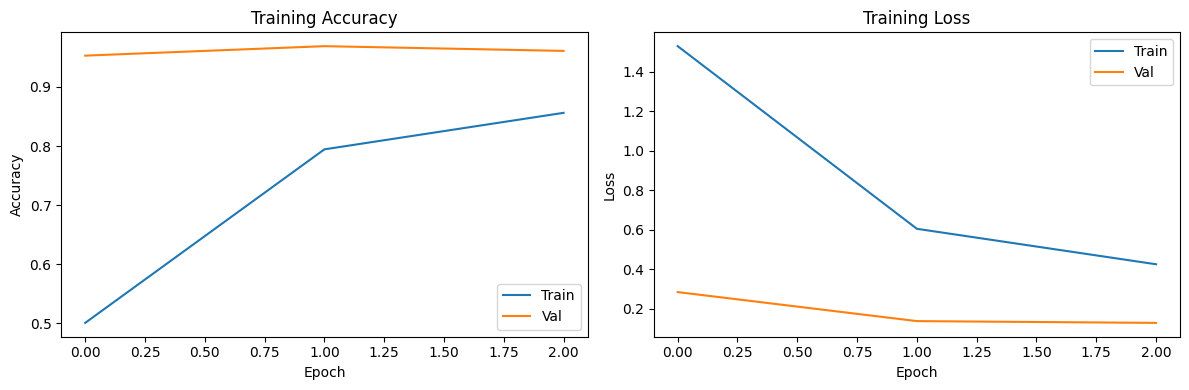

In [9]:
# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

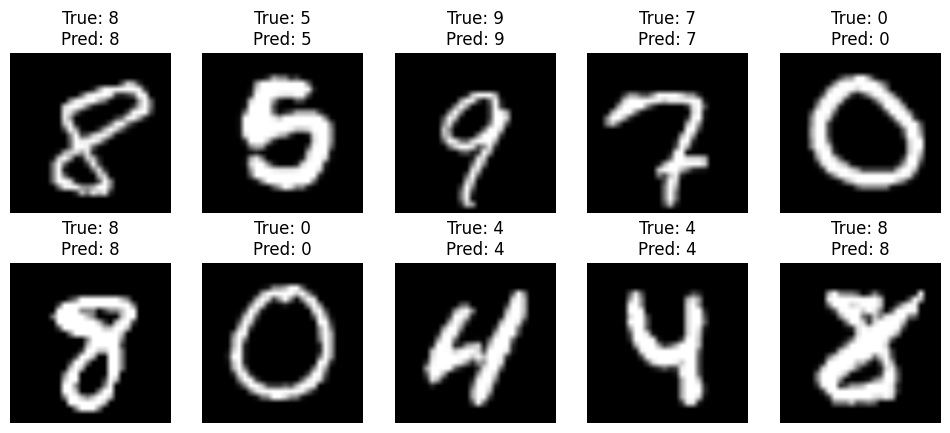

In [19]:
# Show predictions on test images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
indices = np.random.choice(len(x_test), 10, replace=False)

for i, idx in enumerate(indices):
    ax = axes[i // 5, i % 5]
    
    # Predict
    pred = model.predict(x_test[idx:idx+1], verbose=0)
    pred_label = np.argmax(pred)
    true_label = np.argmax(y_test[idx])
    
    # Display
    ax.imshow(x_test[idx][:,:,0], cmap='gray')
    ax.set_title(f'True: {true_label}\nPred: {pred_label}')
    ax.axis('off')


plt.show()